# Project 2: Fraud Detection Pipeline


## 1. Import Libraries and Load Dataset

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, roc_auc_score, roc_curve, classification_report
from sklearn.neighbors import NearestNeighbors
from sklearn.base import BaseEstimator, ClassifierMixin, clone

# Custom SMOTE resampling implementation

def smote_resample(X, y, k_neighbors=5, random_state=None):
    rng = np.random.RandomState(random_state)
    X = np.asarray(X)
    y = np.asarray(y)
    minority_class = 1
    X_min = X[y == minority_class]
    if len(X_min) < 2:
        return X, y
    neigh = NearestNeighbors(n_neighbors=min(len(X_min), k_neighbors + 1))
    neigh.fit(X_min)
    neighbors = neigh.kneighbors(X_min, return_distance=False)[:, 1:]
    majority_count = np.sum(y == 0)
    target_count = majority_count - X_min.shape[0]
    synthetic_samples = []
    synthetic_targets = []
    for _ in range(target_count):
        idx = rng.randint(0, X_min.shape[0])
        neighbor_idx = rng.choice(neighbors[idx])
        diff = X_min[neighbor_idx] - X_min[idx]
        gap = rng.rand()
        synthetic_samples.append(X_min[idx] + gap * diff)
        synthetic_targets.append(minority_class)
    if synthetic_samples:
        X_syn = np.vstack(synthetic_samples)
        y_syn = np.array(synthetic_targets)
        X_res = np.vstack([X, X_syn])
        y_res = np.hstack([y, y_syn])
    else:
        X_res, y_res = X, y
    return X_res, y_res


class SMOTEClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, classifier=None, k_neighbors=5, random_state=None):
        self.classifier = classifier
        self.k_neighbors = k_neighbors
        self.random_state = random_state

    def fit(self, X, y):
        X_res, y_res = smote_resample(X, y, k_neighbors=self.k_neighbors, random_state=self.random_state)
        self.classifier_ = clone(self.classifier)
        self.classifier_.fit(X_res, y_res)
        return self

    def predict(self, X):
        return self.classifier_.predict(X)

    def predict_proba(self, X):
        return self.classifier_.predict_proba(X)

    def get_params(self, deep=True):
        return {
            'classifier': self.classifier,
            'k_neighbors': self.k_neighbors,
            'random_state': self.random_state,
        }

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

# Create a synthetic imbalanced fraud dataset
X, y = make_classification(
    n_samples=1500,
    n_features=20,
    n_informative=8,
    n_redundant=4,
    n_repeated=0,
    n_classes=2,
    weights=[0.97, 0.03],
    flip_y=0.01,
    class_sep=1.2,
    random_state=42
)

feature_names = [f'feature_{i+1}' for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=feature_names)
df['is_fraud'] = y

df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,is_fraud
0,0.531526,0.631671,0.848759,-1.206428,0.428641,0.642798,-2.633346,-0.479824,-0.173544,0.329613,...,0.999597,2.061539,-1.690844,1.639049,1.404738,-0.568175,1.684682,-0.187855,-2.175104,0
1,3.606165,0.293940,3.083758,1.434803,-1.701217,1.883040,0.884863,1.797352,1.203604,-0.109917,...,1.524867,-1.362941,0.635534,3.461133,-1.162597,-0.464518,1.967699,-1.311600,-2.440511,0
2,2.305343,-0.523839,-2.455484,-0.233745,-2.018209,1.792365,-0.504480,-0.322457,0.997878,0.843243,...,-0.018345,1.416257,-0.462286,1.380945,-0.083039,2.224390,-0.594472,-2.282281,0.333275,0
3,-0.077304,-0.512589,2.920040,-0.123708,-0.002106,1.398448,1.418862,-0.159366,-1.240760,0.735264,...,1.182649,-1.500911,0.617820,1.894378,2.134596,-2.004927,-1.123162,-0.834429,-0.600260,0
4,1.592312,-0.029081,1.717608,1.600541,-4.288045,0.674834,1.709086,0.010734,-1.730781,-0.482358,...,-0.911723,1.796076,-0.658818,0.689039,-1.649857,-0.180504,0.841899,-0.182390,-3.008378,0


## 2. Explore Imbalanced Transaction Data


Dataset shape: (1500, 21)

Target distribution:
is_fraud
0    0.965333
1    0.034667
Name: proportion, dtype: float64


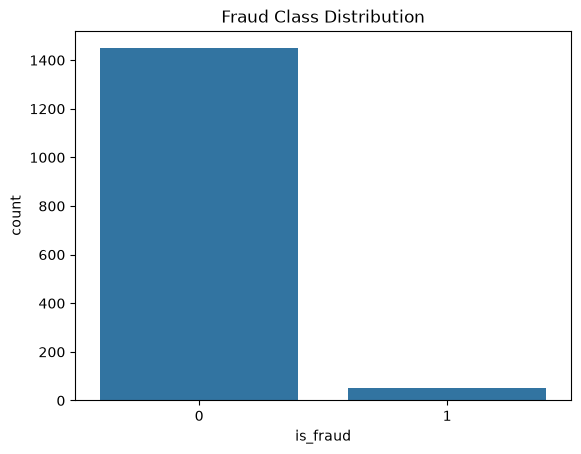

,count,mean,std,min,25%,50%,75%,max
feature_1,1500.0,0.927124,3.005584,-9.983394,-1.012854,1.218215,3.031877,8.359403
feature_2,1500.0,-0.013848,0.990805,-3.264636,-0.694579,-0.015477,0.665435,3.198398
feature_3,1500.0,0.286689,3.109476,-11.922685,-1.635680,0.350450,2.407646,11.433147
feature_4,1500.0,0.107549,1.169102,-3.725592,-0.665299,0.116018,0.890450,3.743224
feature_5,1500.0,-1.251227,1.641779,-6.761333,-2.355471,-1.249743,-0.179056,3.930228
feature_6,1500.0,1.237171,1.415240,-4.750714,0.359603,1.229572,2.056498,6.378169
feature_7,1500.0,0.063884,2.040382,-5.351237,-1.388941,-0.012685,1.388742,6.539531
feature_8,1500.0,0.068412,1.003638,-3.489780,-0.602206,0.046632,0.729692,3.902799
feature_9,1500.0,-0.027779,0.978538,-3.053153,-0.727767,-0.038929,0.662293,3.162417
feature_10,1500.0,0.018531,0.992377,-3.144962,-0.666903,-0.006699,0.684844,2.843450


In [3]:
print('Dataset shape:', df.shape)
print('\nTarget distribution:')
print(df['is_fraud'].value_counts(normalize=True).rename('proportion'))

sns.countplot(x='is_fraud', data=df)
plt.title('Fraud Class Distribution')
plt.xlabel('is_fraud')
plt.ylabel('count')
plt.show()

df.describe().T

## 3. Split Data and Define Pipeline with SMOTE


In [4]:
X = df.drop(columns=['is_fraud'])
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

print('Train fraud ratio:', y_train.mean())
print('Test fraud ratio:', y_test.mean())

logistic_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote_clf', SMOTEClassifier(
        classifier=LogisticRegression(solver='liblinear', random_state=42),
        k_neighbors=5,
        random_state=42
    ))
])

logistic_pipeline

Train fraud ratio: 0.034666666666666665
Test fraud ratio: 0.034666666666666665


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('smote_clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,classifier,LogisticRegre...r='liblinear')
,random_state,42
,k_neighbors,5
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42


## 4. Train Logistic Regression and Random Forest




In [5]:
# Logistic Regression training
logistic_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote_clf', SMOTEClassifier(
        classifier=LogisticRegression(solver='liblinear', random_state=42),
        k_neighbors=5,
        random_state=42
    ))
])

logistic_pipeline.fit(X_train, y_train)

# Random Forest training
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote_clf', SMOTEClassifier(
        classifier=RandomForestClassifier(n_estimators=100, random_state=42),
        k_neighbors=5,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

print('Logistic Regression training complete')
print('Random Forest training complete')

Logistic Regression training complete
Random Forest training complete


## 5. Tune Hyperparameters with Grid Search


In [6]:
param_grid_lr = {
    'smote_clf__classifier__C': [0.01, 0.1, 1.0, 10.0],
    'smote_clf__classifier__penalty': ['l1', 'l2']
}

param_grid_rf = {
    'smote_clf__classifier__n_estimators': [100, 200],
    'smote_clf__classifier__max_depth': [None, 10, 20],
    'smote_clf__classifier__min_samples_split': [2, 5]
}

grid_lr = GridSearchCV(
    logistic_pipeline,
    param_grid_lr,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_rf = GridSearchCV(
    rf_pipeline,
    param_grid_rf,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train, y_train)
grid_rf.fit(X_train, y_train)

print('Best Logistic Regression params:', grid_lr.best_params_)
print('Best Random Forest params:', grid_rf.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


t:\Decodelabs internship\project 1\venv\Lib\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan]
  warnings.warn(


Fitting 5 folds for each of 12 candidates, totalling 60 fits


t:\Decodelabs internship\project 1\venv\Lib\site-packages\sklearn\model_selection\_search.py:1234: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Best Logistic Regression params: {'smote_clf__classifier__C': 0.01, 'smote_clf__classifier__penalty': 'l1'}
Best Random Forest params: {'smote_clf__classifier__max_depth': None, 'smote_clf__classifier__min_samples_split': 2, 'smote_clf__classifier__n_estimators': 100}


## 6. Evaluate Models using Precision, Recall, ROC-AUC


=== Logistic Regression (baseline) ===
Precision: 0.1200
Recall:    0.6923
ROC-AUC:  0.8598
              precision    recall  f1-score   support

           0     0.9867    0.8177    0.8943       362
           1     0.1200    0.6923    0.2045        13

    accuracy                         0.8133       375
   macro avg     0.5533    0.7550    0.5494       375
weighted avg     0.9566    0.8133    0.8703       375


=== Random Forest (baseline) ===
Precision: 0.2857
Recall:    0.3077
ROC-AUC:  0.8812
              precision    recall  f1-score   support

           0     0.9751    0.9724    0.9737       362
           1     0.2857    0.3077    0.2963        13

    accuracy                         0.9493       375
   macro avg     0.6304    0.6400    0.6350       375
weighted avg     0.9512    0.9493    0.9502       375


=== Logistic Regression (tuned) ===
Precision: 0.1200
Recall:    0.6923
ROC-AUC:  0.8598
              precision    recall  f1-score   support

           0     0.986

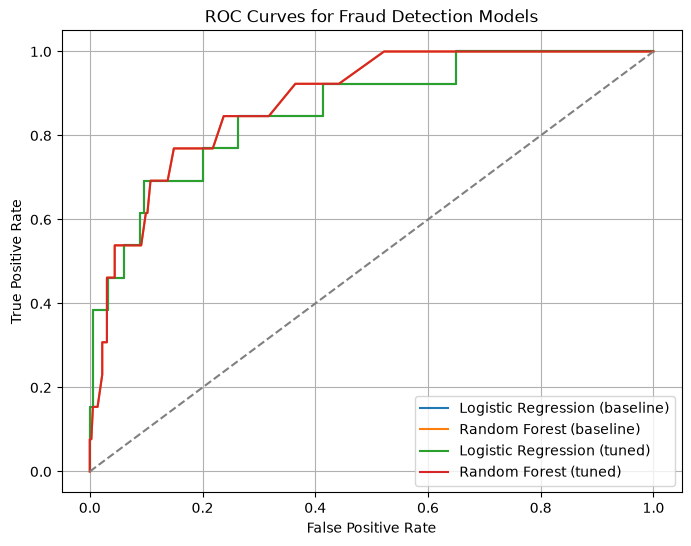

In [7]:
def evaluate_model(model, X_eval, y_eval, model_name):
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]
    precision = precision_score(y_eval, y_pred)
    recall = recall_score(y_eval, y_pred)
    roc_auc = roc_auc_score(y_eval, y_proba)
    print(f'=== {model_name} ===')
    print(f'Precision: {precision:.4f}')
    print(f'Recall:    {recall:.4f}')
    print(f'ROC-AUC:  {roc_auc:.4f}')
    print(classification_report(y_eval, y_pred, digits=4))
    print()
    return y_proba

y_proba_logistic = evaluate_model(logistic_pipeline, X_test, y_test, 'Logistic Regression (baseline)')
y_proba_rf = evaluate_model(rf_pipeline, X_test, y_test, 'Random Forest (baseline)')

y_proba_grid_lr = evaluate_model(grid_lr.best_estimator_, X_test, y_test, 'Logistic Regression (tuned)')
y_proba_grid_rf = evaluate_model(grid_rf.best_estimator_, X_test, y_test, 'Random Forest (tuned)')

plt.figure(figsize=(8, 6))
for proba, label in [
    (y_proba_logistic, 'Logistic Regression (baseline)'),
    (y_proba_rf, 'Random Forest (baseline)'),
    (y_proba_grid_lr, 'Logistic Regression (tuned)'),
    (y_proba_grid_rf, 'Random Forest (tuned)'),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=label)

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Fraud Detection Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()